### ============================================================### Assignment 1 — Student Version### Information Set, Unobserved Component, and Conditional Expectation### ECON 417 · Business Forecasting · SIUE### ============================================================> **Context:** We continue with the Spotify data from Lecture 1.> Taylor Swift's *Anti-Hero* daily global streams (Oct 2022 – Jan 2024, 450 days).> The AR(2) model we built in lecture is our starting point.>> **This file is the answer key.**> The student version has the same structure with fill-in gaps.

---
## Setup — Rebuild the Anti-Hero Dataset & AR(2) Model

Run this cell first. It rebuilds the synthetic stream data (using the same
`np.random.seed(42)` as Lecture 1) and fits the AR(2) model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)          # must match Lecture 1 — keeps data identical

# ── colour palette ────────────────────────────────────────────────────
C_GREEN  = '#1DB954'        # Spotify green  — actual data / known history
C_BLACK  = '#191414'        # Spotify black  — text
C_GRAY   = '#535353'        # Spotify gray   — residual bars / unknown future
C_LIGHT  = '#B3B3B3'        # Spotify light gray
C_ORANGE = '#D6604D'        # conditional expectation / fitted line
C_BLUE   = '#2166AC'        # annotation / highlighted point

plt.rcParams.update({
    'figure.facecolor': 'white',  'axes.facecolor': '#F8F8F8',
    'axes.edgecolor':   '#DDDDDD','axes.grid': True,
    'grid.color':       '#EEEEEE','grid.linewidth': 0.8,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,        'axes.labelsize': 11,
    'xtick.labelsize':  9,         'ytick.labelsize': 9,
})

In [3]:
# ── Rebuild Anti-Hero daily streams (450 days) ───────────────────────
dates    = pd.date_range('2022-10-21', periods=450, freq='D')
n        = len(dates)
base     = 12 * np.exp(-np.arange(n) / 65) + 2.5          # decay curve
weekday  = np.array([d.weekday() for d in dates])
seasonal = np.where(weekday >= 4, 0.45, 0.0)               # Fri/Sat boost
spikes   = np.zeros(n)
spikes[0]   = 8.5    # release day         (Oct 21 2022)
spikes[55]  = 1.8    # Grammy nominations  (Dec 13 2022)
spikes[107] = 2.8    # Grammy win          (Feb  5 2023)
spikes[148] = 2.0    # Eras Tour kick-off  (Mar 18 2023)
spikes[250] = 1.3    # Midnights re-release
noise    = np.random.normal(0, 0.18, n)
streams  = np.clip(base + seasonal + spikes + noise, 0.8, None)
ts       = pd.DataFrame({'streams_M': streams}, index=dates)

# ── Build lag dataset and fit AR(2) ──────────────────────────────────
lag_df = pd.DataFrame({
    'yt':   ts['streams_M'],
    'yt_1': ts['streams_M'].shift(1),
    'yt_2': ts['streams_M'].shift(2),
}).dropna()

X      = lag_df[['yt_1', 'yt_2']].values
y      = lag_df['yt'].values
reg    = LinearRegression().fit(X, y)
fitted = reg.predict(X)          # E[ streams_t | Omega_t ]
resid  = y - fitted              # epsilon_t
sigma  = resid.std()             # spread of unobserved component

print('AR(2) Model — Taylor Swift Anti-Hero Daily Streams')
print('=' * 50)
print(f'  beta_0 = {reg.intercept_:.4f}   (intercept)')
print(f'  beta_1 = {reg.coef_[0]:.4f}   (on y_{{t-1}})')
print(f'  beta_2 = {reg.coef_[1]:.4f}   (on y_{{t-2}})')
print(f'  R²     = {reg.score(X, y):.4f}')
print(f'  sigma  = {sigma:.4f} M   (std of residuals)')
print()
print(f'Model equation:')
print(f'  E[y_t | Ω_t] = {reg.intercept_:.4f} + {reg.coef_[0]:.4f}·y_{{t-1}} + {reg.coef_[1]:.4f}·y_{{t-2}}')

AR(2) Model — Taylor Swift Anti-Hero Daily Streams
  beta_0 = 0.1184   (intercept)
  beta_1 = 0.7924   (on y_{t-1})
  beta_2 = 0.1731   (on y_{t-2})
  R²     = 0.9756
  sigma  = 0.4175 M   (std of residuals)

Model equation:
  E[y_t | Ω_t] = 0.1184 + 0.7924·y_{t-1} + 0.1731·y_{t-2}


---
## Section 1 — Information Set  Ω_t

**Definition:**
> Ω_t is the complete collection of everything you can actually observe
> *up to and including* time t.

Three things to keep in mind:

1. **Hard time boundary** — anything after t is outside Ω_t,
   even if it is almost certain to happen.
2. **"Observable" means recorded and available** — knowing something is
   happening is different from having data on its magnitude.
3. **Your model is limited by Ω_t** — you can only use what you actually have.

#### Q1.1 — Classify the variables below

For each variable, decide whether it belongs in Ω_t at the moment of forecasting
(i.e., on the evening of day 200, *before* you observe day 201's streams).

| Variable | In Ω_t ? | Reason |
|----------|----------|--------|
| Yesterday's stream count (streams_{t-1}) | **Yes** | Already observed, recorded in the dataset |
| The day of the week tomorrow | **Yes** | Calendar is deterministic — always known in advance |
| Whether a celebrity will tweet the song tonight | **No** | Future event — unobservable until it happens |
| The Eras Tour start date (Mar 18, 2023) | **Yes** | Past event, publicly known by day 200 |
| Spotify's next editorial playlist update | **No** | Internal decision, not publicly observable |
| The Grammy nomination date (Dec 13, 2022) | **Yes** | Past event, fully in the public record |
| Number of TikTok videos made tomorrow | **No** | Future — will only be known after the fact |

#### Q1.2 — Plot the Information Set Boundary

The plot below draws the hard line between what is known (Ω_t)
and what is unknown at the moment of forecasting.

Forecasting from: 2023-05-11  (day 200)


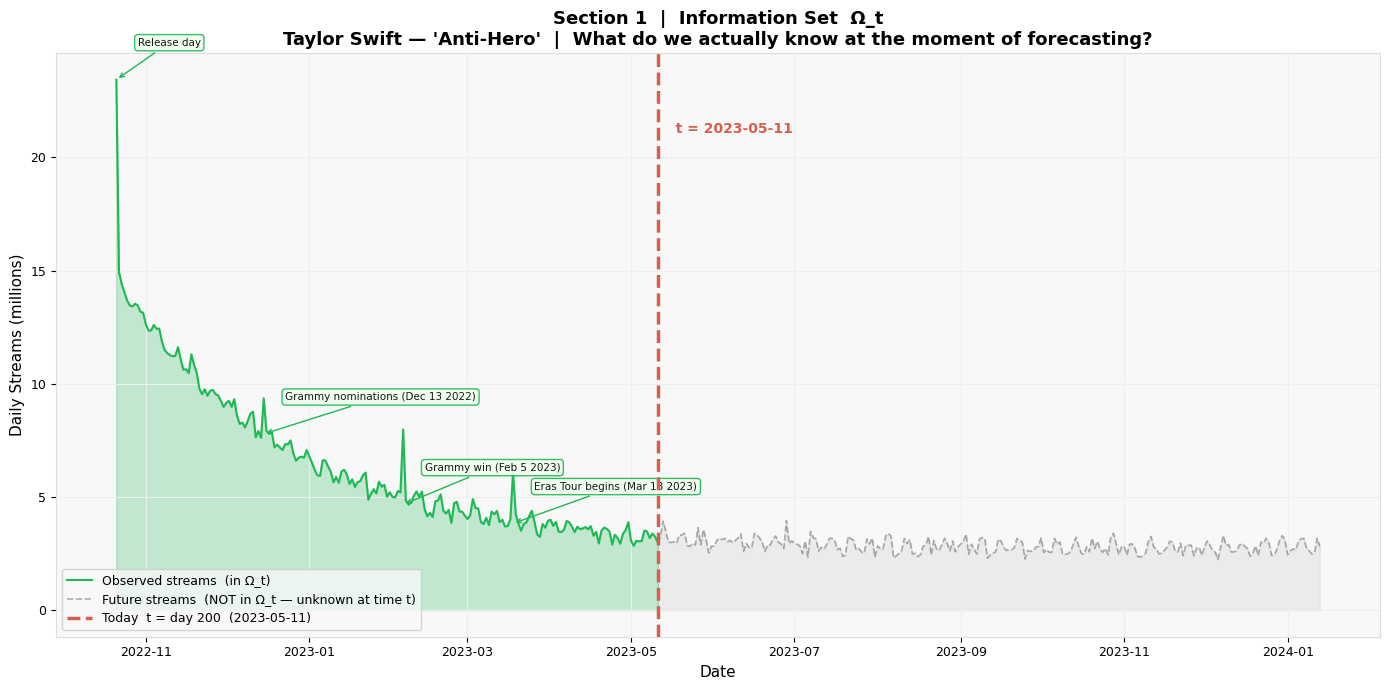

In [5]:
TODAY_IDX = 200                        # standing at day 200

today = lag_df.index[TODAY_IDX]
print(f'Forecasting from: {today.date()}  (day {TODAY_IDX})')

fig, ax = plt.subplots(figsize=(14, 7))

# ── known history (in Omega_t) ────────────────────────────────────────
known = ts.loc[:today]
ax.fill_between(known.index, known['streams_M'], alpha=0.25, color=C_GREEN)
ax.plot(known.index, known['streams_M'], color=C_GREEN, lw=1.5,
        label='Observed streams  (in Ω_t)')

# ── unknown future (outside Omega_t) ────────────────────────────────
future = ts.loc[today:]
ax.fill_between(future.index, future['streams_M'], alpha=0.08, color=C_GRAY)
ax.plot(future.index, future['streams_M'], color=C_GRAY, lw=1.2, ls='--', alpha=0.45,
        label='Future streams  (NOT in Ω_t — unknown at time t)')

# ── 'today' dividing line ─────────────────────────────────────────────
ax.axvline(today, color=C_ORANGE, lw=2.5, ls='--', zorder=5,
           label=f'Today  t = day {TODAY_IDX}  ({today.date()})')
ax.text(today + pd.Timedelta(days=3), known['streams_M'].max() * 0.92,
        f'  t = {today.date()}', color=C_ORANGE,
        fontsize=10, fontweight='bold', va='top')

# ── annotate known events in Omega_t ────────────────────────────────
past_events = [
    (0,   streams[0],   'Release day'),
    (55,  streams[57],  'Grammy nominations (Dec 13 2022)'),
    (107, streams[109], 'Grammy win (Feb 5 2023)'),
    (148, streams[150], 'Eras Tour begins (Mar 18 2023)'),
]
for idx, yval, label in past_events:
    if idx < TODAY_IDX:
        xval = ts.index[idx]
        ax.annotate(label,
                    xy=(xval, yval),
                    xytext=(xval + pd.Timedelta(days=8), yval + 1.5),
                    arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.0),
                    fontsize=7.5, color=C_BLACK,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FFF0',
                              edgecolor=C_GREEN, alpha=0.9))

# ── text boxes ────────────────────────────────────────────────────────
omega_txt = (
    # TODO: fill in what belongs in Omega_t (at least 4 items)
    # Format: '✓  item description\n'
    ''
)
ax.text(0.02, 0.97, omega_txt, transform=ax.transAxes,
        fontsize=9, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0FFF0',
                  edgecolor=C_GREEN, alpha=0.95))

unobs_txt = (
    # TODO: fill in what is NOT in Omega_t (at least 3 items)
    # Format: '✗  item description\n'
    ''
)
ax.text(0.58, 0.97, unobs_txt, transform=ax.transAxes,
        fontsize=9, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF4F0',
                  edgecolor=C_ORANGE, alpha=0.95))

ax.set_ylabel('Daily Streams (millions)')
ax.set_xlabel('Date')
ax.set_title(
    "Section 1  |  Information Set  Ω_t\n"
    "Taylor Swift — 'Anti-Hero'  |  What do we actually know at the moment of forecasting?",
    fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

#### Q1.3 — Short Answer Suppose today is day 200 (April 8, 2023).The Eras Tour started on March 18, 2023 (day 148).1. 

1. **Is the Eras Tour start date inside Ω_{200}? Why or why not?**  

 > *[Your answer here]*

2. **Can you use the *fact that the tour is still ongoing* on day 200 as part of Ω_{200}?**   

> *[Your answer here]*

3. **Name one thing that is real, measurable, and affects streams — but is still outside Ω_{200}.**   

> *[Your answer here]*

---
## Section 2 — Unobserved Component  ε_t

**Definition:**
> ε_t is everything that actually drove y_t but was NOT contained in Ω_t.

It is not random noise invented by statisticians — **it is real.**
It has real causes. We just do not have data on those causes.

There are three categories of things that end up in ε_t:

| Category | Description | Example |
|----------|-------------|---------|
| **Missing data** | Exists but wasn't collected | Real-time TikTok view counts |
| **Future events** | Known to happen, magnitude unknown | Grammy win — we knew the ceremony date, not the outcome |
| **Unmodelled interactions** | Too complex to capture | How tour excitement amplifies playlist behaviour |

The equation:

&emsp; streams_t &nbsp; = &nbsp; **E[ streams_t | Ω_t ]** &nbsp; + &nbsp; **ε_t**

&emsp; &emsp; &emsp; actual = what model predicted + what model missed

#### Q2.1 — Plot Actual vs Conditional Expectation, then plot ε_t

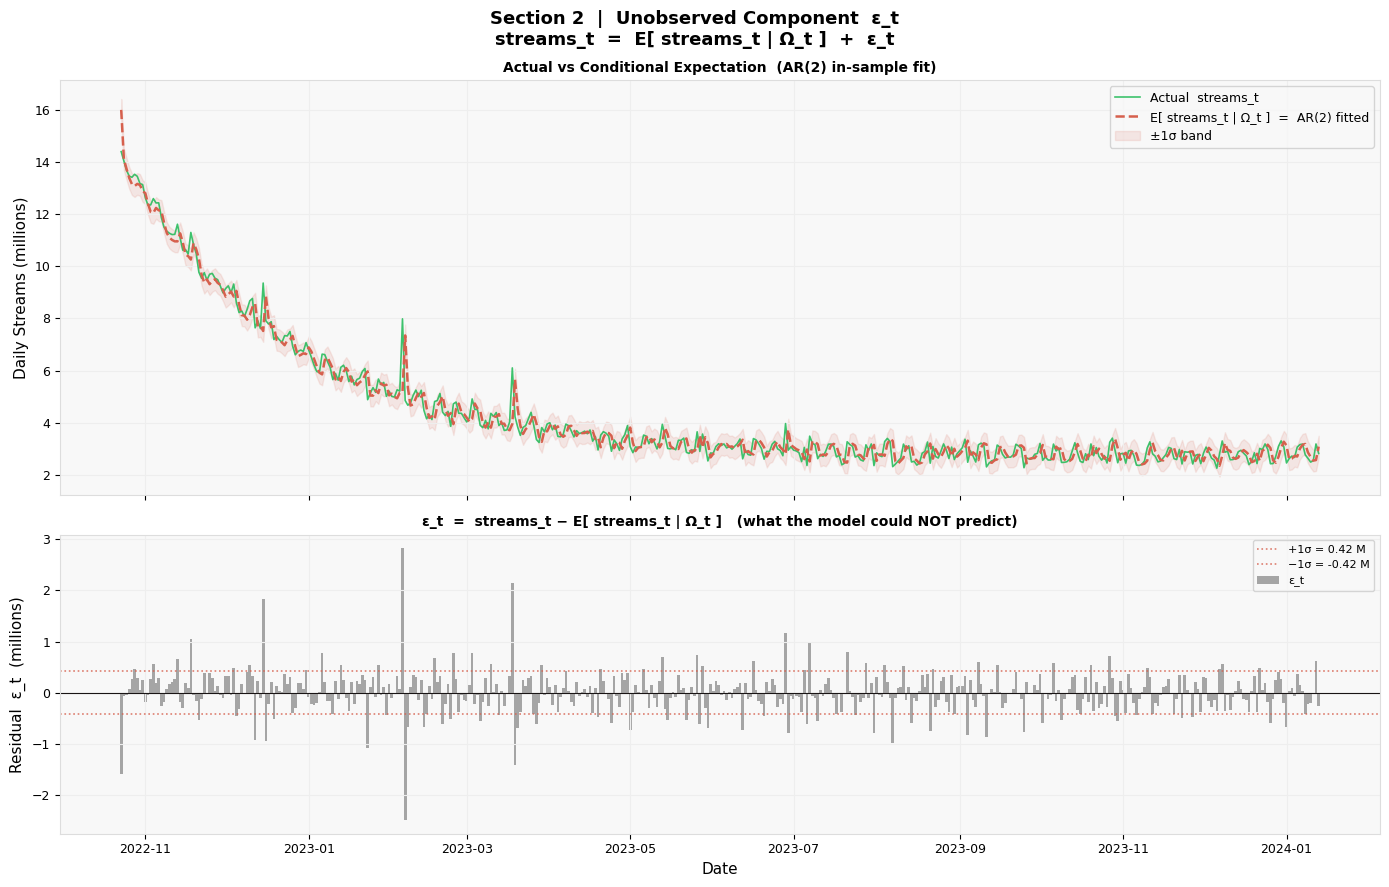

In [7]:
fig, axes = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1.8]}
)
fig.suptitle(
    'Section 2  |  Unobserved Component  ε_t\n'
    'streams_t  =  E[ streams_t | Ω_t ]  +  ε_t',
    fontweight='bold', fontsize=13
)

# ── top panel: actual vs fitted ──────────────────────────────────────
ax = axes[0]
ax.plot(
    lag_df.index, y,
    color=C_GREEN, lw=1.2, alpha=0.85,
    label='Actual  streams_t'
)
ax.plot(
    lag_df.index, fitted,
    color=C_ORANGE, lw=1.8, ls='--',
    label='E[ streams_t | Ω_t ]  =  AR(2) fitted'
)
ax.fill_between(
    lag_df.index, fitted - sigma, fitted + sigma,
    alpha=0.12, color=C_ORANGE, label='±1σ band'
)
ax.set_ylabel('Daily Streams (millions)')
ax.set_title(
    'Actual vs Conditional Expectation  (AR(2) in-sample fit)',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=9)

# ── bottom panel: residuals = epsilon_t ──────────────────────────────
ax = axes[1]
ax.bar(
    lag_df.index, resid,
    color=C_GRAY, alpha=0.50, width=1.0, label='ε_t'
)
ax.axhline(0, color=C_BLACK, lw=0.8)
ax.axhline(
    sigma, color=C_ORANGE, lw=1.2, ls=':', alpha=0.8,
    label=f'+1σ = {sigma:.2f} M'
)
ax.axhline(
    -sigma, color=C_ORANGE, lw=1.2, ls=':', alpha=0.8,
    label=f'−1σ = {-sigma:.2f} M'
)

# annotate known causes
events = [
    # TODO: add at least 3 annotated events
    # Format: (day_index, y_annotation_height, 'label text')
]
for idx, y_ann, label in events:
    xval = lag_df.index[idx]
    ax.annotate(
        label, xy=(xval, resid[idx]), xytext=(xval, y_ann),
        arrowprops=dict(arrowstyle='->', color=C_ORANGE, lw=1.1),
        fontsize=7.5, ha='center', color=C_BLACK,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_LIGHT, alpha=0.9)
    )

ax.set_ylabel('Residual  ε_t  (millions)')
ax.set_xlabel('Date')
ax.set_title(
    'ε_t  =  streams_t − E[ streams_t | Ω_t ]   (what the model could NOT predict)',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

#### Q2.2 — Interpret the Residuals  *(write your response in the next cell)

####Look at the residual plot above.
**1.On the Grammy win day (day 107), the residual is large and positive.   Explain in one sentence why ε_{107} > 0 in terms of Ω_t.** 


> *[Your answer here]*

***2. Most residuals are small and centred around zero.   What does this tell you about the AR(2) model?**

> *[Your answer here]*

***3.The ±1σ dotted lines mark roughly one standard deviation.   What fraction of residuals do you expect to fall outside that band?**

> *[Your answer here]*

---
## Section 3 — Conditional Expectation  E[ streams_t | Ω_t ]

**Definition:**
> E[ streams_t | Ω_t ] is the mean of the distribution of streams_t,
> given everything in Ω_t.

This is what your model produces — not streams_t itself,
but your best estimate *before* it is realised.

Two things follow directly:

- **The model is never exactly right** — ε_t ≠ 0 in any individual period.
- **A wider σ means more uncertainty** — the conditional distribution is more spread out.

#### Q3.1 — Plot E[ streams_t | Ω_t ] with Uncertainty Bands

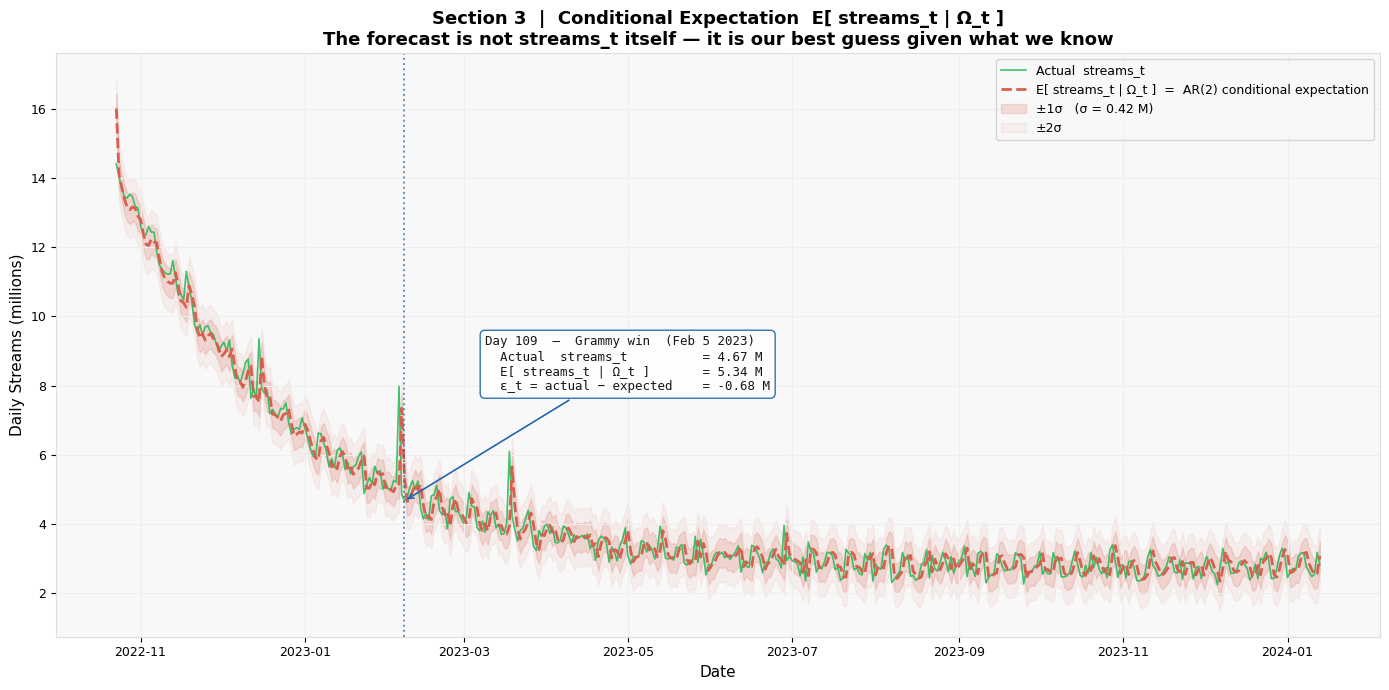

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

# ── actual ─────────────────────────────────────────────────────────
ax.plot(lag_df.index, y,
        color=C_GREEN, lw=1.2, alpha=0.85,
        label='Actual  streams_t')

# ── conditional expectation ─────────────────────────────────────────
ax.plot(lag_df.index, fitted,
        color=C_ORANGE, lw=2.0, ls='--',
        label='E[ streams_t | Ω_t ]  =  AR(2) conditional expectation')

# ── uncertainty bands ───────────────────────────────────────────────
ax.fill_between(lag_df.index,
                fitted - sigma, fitted + sigma,
                alpha=0.18, color=C_ORANGE,
                label=f'±1σ   (σ = {sigma:.2f} M)')
ax.fill_between(lag_df.index,
                fitted - 2*sigma, fitted + 2*sigma,
                alpha=0.07, color=C_ORANGE,
                label='±2σ')

# ── annotate the Grammy win day ─────────────────────────────────────
day_i    = 107
day_date = lag_df.index[day_i]
ax.axvline(day_date, color=C_BLUE, lw=1.4, ls=':', alpha=0.7)
ax.annotate(
    f'Day {day_i + 2}  —  Grammy win  (Feb 5 2023)\n'
    f'  Actual  streams_t          = {y[day_i]:.2f} M\n'
    f'  E[ streams_t | Ω_t ]       = {fitted[day_i]:.2f} M\n'
    f'  ε_t = actual − expected    = {resid[day_i]:+.2f} M',
    xy=(day_date, y[day_i]),
    xytext=(day_date + pd.Timedelta(days=30), y[day_i] + 3.2),
    arrowprops=dict(arrowstyle='->', color=C_BLUE, lw=1.2),
    fontsize=9, color=C_BLACK, family='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor=C_BLUE, alpha=0.92))

ax.set_ylabel('Daily Streams (millions)')
ax.set_xlabel('Date')
ax.set_title(
    "Section 3  |  Conditional Expectation  E[ streams_t | Ω_t ]\n"
    "The forecast is not streams_t itself — it is our best guess given what we know",
    fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

#### Q3.2 — Read the Plot. Use the annotated point (Grammy win day) and the uncertainty bands to answer:

1. **On the Grammy win day, read E[streams_t | Ω_t] and actual streams_t from the annotation.   Compute ε_t. Is the model over or under predicting?** 

> *[Your answer here — read the numbers from the annotation above]

*2. **The ±1σ band has width σ on each side. What does it represent in plain English?**  

> *[Your answer here]

*3. **On most ordinary days, actual streams fall inside the ±1σ band.   What does this tell you about where the "interesting" forecasting errors occur?**  

 > *[Your answer here]*

#### Q3.3 — Compute Conditional Expectation for a New Day

In [12]:
# Use the AR(2) formula to manually compute E[ y_{T+1} | Omega_T ]
# for the day AFTER the last observation in our dataset.

b0      = reg.intercept_
b1, b2  = reg.coef_[0], reg.coef_[1]
y_T     = lag_df['yt'].iloc[-1]       # y_T   (most recent observation)
y_T1    = lag_df['yt'].iloc[-2]       # y_{T-1}
date_T  = lag_df.index[-1]

E_next  = b0 + b1 * y_T + b2 * y_T1

print('One-step-ahead conditional expectation')
print('=' * 55)
print(f'  Model date T        : {date_T.date()}')
print(f'  y_T                 : {y_T:.4f} M   (last observed streams)')
print(f'  y_{{T-1}}             : {y_T1:.4f} M')
print()
print(f'  E[y_{{T+1}} | Ω_T]  =  {b0:.4f}')
print(f'                      +  {b1:.4f} × {y_T:.4f}')
print(f'                      +  {b2:.4f} × {y_T1:.4f}')
print(f'                      =  {E_next:.4f} M')
print()
print(f'  Uncertainty:')
print(f'    ±1σ  →  [{E_next - sigma:.4f} M,  {E_next + sigma:.4f} M]')
print(f'    ±2σ  →  [{E_next - 2*sigma:.4f} M,  {E_next + 2*sigma:.4f} M]')
print()
print('Note: this is an IN-SAMPLE conditional expectation.')
print('Out-of-sample forecasting and why the gap widens comes in the next lecture.')

One-step-ahead conditional expectation
  Model date T        : 2024-01-13
  y_T                 : 2.8150 M   (last observed streams)
  y_{T-1}             : 3.1794 M

  E[y_{T+1} | Ω_T]  =  0.1184
                      +  0.7924 × 2.8150
                      +  0.1731 × 3.1794
                      =  2.8992 M

  Uncertainty:
    ±1σ  →  [2.4817 M,  3.3168 M]
    ±2σ  →  [2.0642 M,  3.7343 M]

Note: this is an IN-SAMPLE conditional expectation.
Out-of-sample forecasting and why the gap widens comes in the next lecture.


---
## Summary

In [11]:
print('=' * 65)
print('ASSIGNMENT 1 — CONCEPT SUMMARY')
print('=' * 65)
print()
print('  streams_t  =  E[ streams_t | Ω_t ]  +  ε_t')
print()
concepts = [
    ('Ω_t',
     'Information set',
     'Everything observable up to and including time t.',
     'Historical streams, release date, Grammy dates, tour schedule.'),
    ('E[ streams_t | Ω_t ]',
     'Conditional expectation',
     'Best forecast given Ω_t.  What the AR(2) model produces.',
     'The orange dashed line in the plots.'),
    ('ε_t',
     'Unobserved component',
     'Real drivers of streams_t that were NOT in Ω_t.',
     'Grammy win outcome, viral tweets, Spotify algorithmic pushes.'),
]
for symbol, name, definition, example in concepts:
    print(f'  {symbol}')
    print(f'    Name       : {name}')
    print(f'    Definition : {definition}')
    print(f'    Example    : {example}')
    print()
print('A better Ω_t (more relevant data) → smaller ε_t → better forecast.')
print('But ε_t can never be zero: some drivers will always be unobservable.')

ASSIGNMENT 1 — CONCEPT SUMMARY

  streams_t  =  E[ streams_t | Ω_t ]  +  ε_t

  Ω_t
    Name       : Information set
    Definition : Everything observable up to and including time t.
    Example    : Historical streams, release date, Grammy dates, tour schedule.

  E[ streams_t | Ω_t ]
    Name       : Conditional expectation
    Definition : Best forecast given Ω_t.  What the AR(2) model produces.
    Example    : The orange dashed line in the plots.

  ε_t
    Name       : Unobserved component
    Definition : Real drivers of streams_t that were NOT in Ω_t.
    Example    : Grammy win outcome, viral tweets, Spotify algorithmic pushes.

A better Ω_t (more relevant data) → smaller ε_t → better forecast.
But ε_t can never be zero: some drivers will always be unobservable.
